## Set up

In [17]:
import numpy as np

import tensorflow_datasets as tfds
import tensorflow as tf

tfds.disable_progress_bar()

import matplotlib.pyplot as plt

## Set up input pipeline

In [18]:
"""Download data using TFDS"""
dataset, info = tfds.load('imdb_reviews', with_info=True,
                          as_supervised=True)

train_dataset, test_dataset = dataset['train'], dataset['test']

train_dataset.element_spec

"""Initially this returns a dataset of (text, label pairs)"""
for example, label in train_dataset.take(1):
    print('text: ', example.numpy())
    print('label: ', label.numpy())

"""Set value for shuffle data and initialize batch size"""
BUFFER_SIZE = 10000
BATCH_SIZE = 64

train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

for example, label in train_dataset.take(1):
    print('texts: ', example.numpy()[:3])
    print()
    print('labels: ', label.numpy()[:3])

text:  b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it."
label:  0
texts:  [b'I actually paid to see this movie in the theater.<br /><br />It would get a 1-rating, but the fight scenes between the robots are okay, and there\'s a surprise.<br /><br />I realize that some movies have larger budgets than others. I don\'t have a problem wit

## Functions

In [19]:
def plot_graphs(history, metric):
    plt.plot(history.history[metric])
    plt.plot(history.history['val_'+metric], '')
    plt.xlabel('Epochs')
    plt.ylabel(metric)
    plt.legend([metric, 'val_'+metric])
    plt.show()

## Create the text encoder
The raw text loaded by tfds needs to be processed before it can be used in a model. The simplest way to process text for training is using the TextVectorization layer. This layer has many capabilities, but this tutorial sticks to the default behavior.

In [20]:
"""Create the layer, and pass the dataset's text to lthe layer's .adapt() method"""
VOCAB_SIZE = 2500
encoder = tf.keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE)
""""The .adapt method sets the layer's vocabulary. ที่เข้าใจคือ เหมือนเอาคำศัพท์มาสร้างเป็น Vocabulary"""
encoder.adapt(train_dataset.map(lambda text, label:text))

In [21]:
""" Here are the first 20 tokens. After the padding and unknown tokens they're sorted by frequency"""
vocab = np.array(encoder.get_vocabulary())
vocab[:20]

array(['', '[UNK]', 'the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i',
       'this', 'that', 'br', 'was', 'as', 'for', 'with', 'movie', 'but'],
      dtype='<U14')

In [22]:
"""แปลง text เป็นตัวเลข (indices)"""
encoded_example = encoder(example)[:3].numpy()
encoded_example

array([[  10,  157, 1492, ...,    0,    0,    0],
       [  11,    7,  518, ...,    0,    0,    0],
       [  10,  434,    2, ...,    0,    0,    0]], dtype=int64)

In [23]:
for n in range(3):
    print("original: ", example[n].numpy())
    print("Round-trip: ", " ".join(vocab[encoded_example[n]]))
    print()

original:  b'I actually paid to see this movie in the theater.<br /><br />It would get a 1-rating, but the fight scenes between the robots are okay, and there\'s a surprise.<br /><br />I realize that some movies have larger budgets than others. I don\'t have a problem with that. Unfortunately, science fiction movies probably suffer the most on a small budget for obvious reasons. But, one way this movie fails is that just about every piece of each set looked cheesy and cheap. I mean, couldn\'t they even make it "look" good?<br /><br />The other major reason this movie is horrible is the acting If I watched the movie now and knew what to expect, I might just enjoy it for the cheese-factor, but at the time, I was expecting a good movie and had no clue as to how horrible it would actually end up being.<br /><br />Thankfully, the experience was over in only 85 minutes.'
Round-trip:  i actually paid to see this movie in the [UNK] br it would get a [UNK] but the fight scenes between the [UNK]

## Create the model

In [24]:
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=512,
        mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [25]:
print([layer.supports_masking for layer in model.layers])

[False, True, True, True, True]


In [26]:
"""Compile model"""
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])

In [27]:
"""Train the model"""
history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=test_dataset,
                    validation_steps=30)

Epoch 1/10
391/391 [==============================] - 50s 111ms/step - loss: 0.5317 - accuracy: 0.6776 - val_loss: 0.3752 - val_accuracy: 0.8203
Epoch 2/10
391/391 [==============================] - 41s 105ms/step - loss: 0.3043 - accuracy: 0.8730 - val_loss: 0.3005 - val_accuracy: 0.8755
Epoch 3/10
391/391 [==============================] - 41s 105ms/step - loss: 0.2599 - accuracy: 0.8938 - val_loss: 0.2970 - val_accuracy: 0.8760
Epoch 4/10
391/391 [==============================] - 41s 105ms/step - loss: 0.2399 - accuracy: 0.9019 - val_loss: 0.2962 - val_accuracy: 0.8839
Epoch 5/10
391/391 [==============================] - 41s 104ms/step - loss: 0.2297 - accuracy: 0.9063 - val_loss: 0.3025 - val_accuracy: 0.8849
Epoch 6/10
391/391 [==============================] - 41s 105ms/step - loss: 0.2199 - accuracy: 0.9118 - val_loss: 0.2986 - val_accuracy: 0.8703
Epoch 7/10
391/391 [==============================] - 41s 104ms/step - loss: 0.2079 - accuracy: 0.9181 - val_loss: 0.3130 - val_ac

In [28]:
test_loss, test_acc = model.evaluate(test_dataset, verbose=1)

print('Test Loss: ', test_loss)
print('Test Accuracy: ', test_acc)

391/391 [==============================] - 19s 50ms/step - loss: 0.3165 - accuracy: 0.8708
Test Loss:  0.3164682686328888
Test Accuracy:  0.8707600235939026


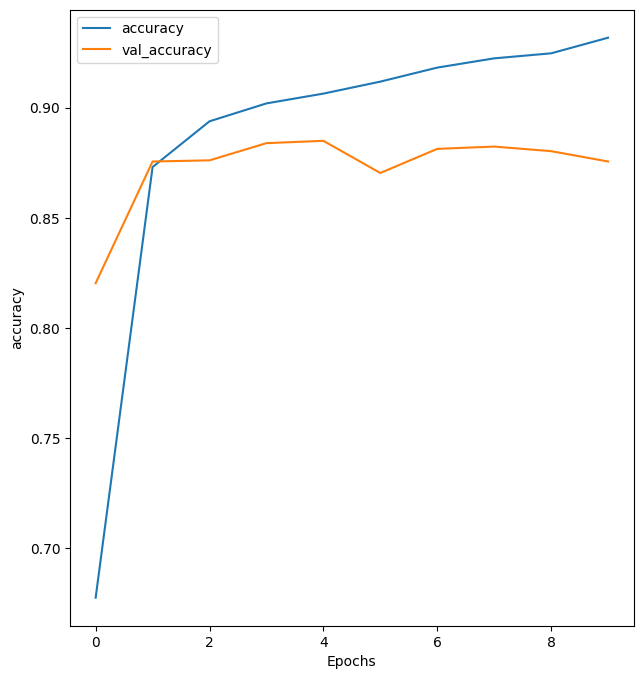

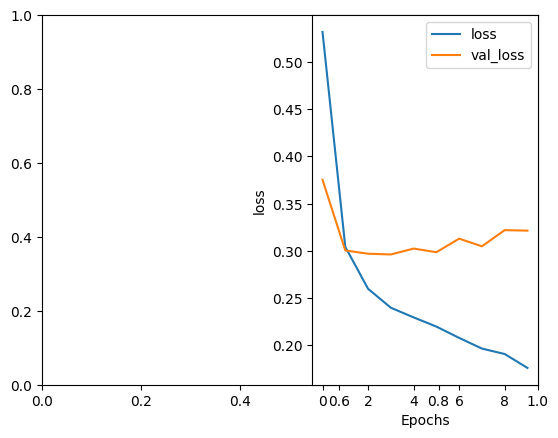

(0.0, 1.0)

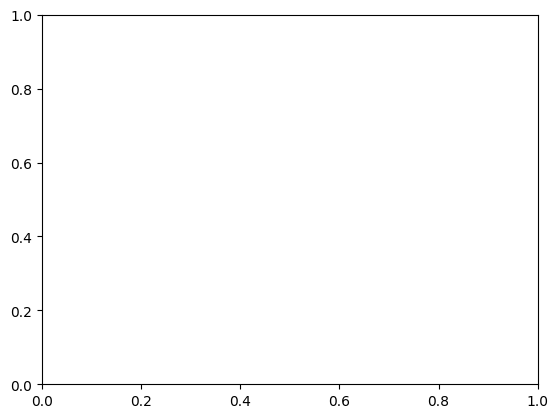

In [29]:
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')
plt.ylim(0, None)

In [51]:
sample_text = ('The movie was cool. The animation and the graphics '
               'were out of this world. I would recommend this movie.')
predictions = model.predict(np.array([sample_text]))

1/1 [==============================] - 0s 21ms/step


In [52]:
if predictions[0] < 0:
    print("Negative comment.")
else:
    print("Positive comment.")

Positive comment.
